# Package Installation

In [1]:
# Install required libraries
!pip -q install transformers datasets sentencepiece evaluate rouge_score accelerate
!pip -q install peft
!pip -q install --upgrade torchao peft transformers accelerate

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 144.1 MB/s eta 0:00:00


# Imports

In [2]:
# Required Imports

import os
import json
import math
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    get_linear_schedule_with_warmup
)
import evaluate

# Setting Seed
SEED = 42

# Random seed=42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


from peft import LoraConfig, TaskType, get_peft_model
from transformers import get_linear_schedule_with_warmup

In [3]:
# Device setup - if its using GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Sample Dataset
## Loading

In [4]:
# Sample data with 20 samples

DATA_PATH = "/content/sample_papers_100.jsonl"

def load_jsonl(path):
    """
    Load a JSONL file where each line is a JSON object.
    Expected fields:
      - paper_text
      - summary
    """
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)

            # Basic validation
            if "paper_text" not in item or "summary" not in item:
                raise ValueError("Each row must contain 'paper_text' and 'summary'.")

            rows.append(item)
    return rows

data = load_jsonl(DATA_PATH)

print("Total examples:", len(data))
print("\nFirst example:")
print(data[0])

Total examples: 100

First example:
{'id': 'sample_001', 'paper_text': 'Large language models have shown strong performance in text generation, but retrieval-augmented generation remains challenging. This work applies structured prompting to improve reliability and reduce errors in generated scientific summaries. The results indicate that the method improves phrase-level overlap with reference summaries. A remaining limitation is that long inputs require truncation.', 'summary': 'The paper investigates retrieval-augmented generation with structured prompting and finds that it improves phrase-level overlap with reference summaries, although long inputs require truncation.'}


# Train/Test/Validation

In [5]:
# Shuffle before splitting
random.shuffle(data)

n = len(data)

train_data = data[:int(0.7*n)]
val_data = data[int(0.7*n):int(0.85*n)]
test_data = data[int(0.85*n):]
print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))

Train size: 70
Validation size: 15
Test size: 15


# Loading an existing tokenizer

In [6]:
# Using an exixting tokenizer from Hugging face- Flan-T5-Small

MODEL_NAME = "google/flan-t5-small"

# Load pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Print tokenizer info
print("Tokenizer loaded:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: google/flan-t5-small
Vocabulary size: 32100


#Prompt builder + tokenizer

In [7]:
MAX_INPUT_LEN = 512
MAX_TARGET_LEN = 96

def build_prompt(example):
    """
    Cleaner prompt to reduce repetition and copying.
    Structured but short.
    """
    return (
        "Summarize the following scientific text. "
        "Write one concise summary covering the problem, method, and key finding.\n\n"
        f"Text:\n{example['paper_text']}"
    )

# Diagnostics on first 2 examples with token IDs
for i, ex in enumerate(train_data[:2]):
    prompt = build_prompt(ex)
    encoding = tokenizer(prompt, truncation=True, max_length=MAX_INPUT_LEN)

    print(f"\nExample {i+1}")
    print("Prompt snippet:", prompt[:180], "...")
    print("Token count:", len(encoding["input_ids"]))
    print("First 20 token IDs:", encoding["input_ids"][:20])


Example 1
Prompt snippet: Summarize the following scientific text. Write one concise summary covering the problem, method, and key finding.

Text:
This research investigates how human-in-the-loop error anal ...
Token count: 84
First 20 token IDs: [12198, 1635, 1737, 8, 826, 4290, 1499, 5, 8733, 80, 22874, 9251, 6013, 8, 682, 6, 1573, 6, 11, 843]

Example 2
Prompt snippet: Summarize the following scientific text. Write one concise summary covering the problem, method, and key finding.

Text:
Scientific documents are difficult to summarize because the ...
Token count: 94
First 20 token IDs: [12198, 1635, 1737, 8, 826, 4290, 1499, 5, 8733, 80, 22874, 9251, 6013, 8, 682, 6, 1573, 6, 11, 843]


# Dataset class

In [8]:
class PaperSummaryDataset(Dataset):
    """
    Custom PyTorch dataset for summarization.
    Each item returns:
      - input_ids
      - attention_mask
      - labels
    """

    def __init__(self, rows, tokenizer, max_input_len=512, max_target_len=96):
        self.rows = rows
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]

        # Build model input prompt
        source_text = build_prompt(row)
        target_text = row["summary"]

        # Tokenize input text
        source = self.tokenizer(
            source_text,
            max_length=self.max_input_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        # Tokenize target summary
        target = self.tokenizer(
            target_text,
            max_length=self.max_target_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        input_ids = source["input_ids"].squeeze(0)
        attention_mask = source["attention_mask"].squeeze(0)
        labels = target["input_ids"].squeeze(0)

        # Ignore padding tokens in loss calculation
        labels[labels == tokenizer.pad_token_id] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

# Creating datasets and dataloaders

In [9]:
train_dataset = PaperSummaryDataset(
    train_data,
    tokenizer,
    max_input_len=MAX_INPUT_LEN,
    max_target_len=MAX_TARGET_LEN
)

val_dataset = PaperSummaryDataset(
    val_data,
    tokenizer,
    max_input_len=MAX_INPUT_LEN,
    max_target_len=MAX_TARGET_LEN
)

BATCH_SIZE = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Check one batch
batch = next(iter(train_loader))

print("input_ids shape:", batch["input_ids"].shape)
print("attention_mask shape:", batch["attention_mask"].shape)
print("labels shape:", batch["labels"].shape)

input_ids shape: torch.Size([4, 512])
attention_mask shape: torch.Size([4, 512])
labels shape: torch.Size([4, 96])


# Loading pretrained model

In [10]:
# Loading FLAN-T5 model
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model.to(device)

# Parameter counts
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model loaded:", MODEL_NAME)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded: google/flan-t5-small
Total parameters: 76,961,152
Trainable parameters: 76,961,152


# Optimizer, scheduler, and ROUGE

In [11]:
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 3
GRAD_ACCUM_STEPS = 2

# AdamW optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Number of optimization steps(EPOCHS)
num_update_steps_per_epoch = max(1, math.ceil(len(train_loader) / GRAD_ACCUM_STEPS))
max_train_steps = NUM_EPOCHS * num_update_steps_per_epoch
warmup_steps = max(1, int(0.1 * max_train_steps))

# Linear learning rate scheduler with warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=max_train_steps
)

# ROUGE evaluator
rouge = evaluate.load("rouge")

# Evaluation functions

In [12]:
@torch.no_grad()
def evaluate_loss(model, loader):
    """
    Compute average validation loss.
    """
    model.eval()
    losses = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        losses.append(outputs.loss.item())

    return float(np.mean(losses)) if losses else float("nan")


@torch.no_grad()
def generate_predictions(model, loader, max_gen_len=96):
    """
    Generate summaries for validation data.
    Includes anti-repetition controls.
    """
    model.eval()
    preds = []
    refs = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].clone()

        generated_ids = model.generate(
          input_ids=input_ids,
          attention_mask=attention_mask,
          max_length=max_gen_len,
          min_length=25,
          num_beams=3,
          repetition_penalty=1.8,
          no_repeat_ngram_size=3,
          length_penalty=1.2,
          early_stopping=True
        )

        decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

        labels[labels == -100] = tokenizer.pad_token_id
        decoded_refs = tokenizer.batch_decode(labels, skip_special_tokens=True)

        preds.extend(decoded_preds)
        refs.extend(decoded_refs)

    return preds, refs


@torch.no_grad()
def evaluate_rouge(model, loader):
    """
    Compute ROUGE scores using generated summaries.
    """
    preds, refs = generate_predictions(model, loader)
    scores = rouge.compute(predictions=preds, references=refs)
    return scores, preds, refs

# Training loop

In [13]:
OUTPUT_DIR = "results_base_model"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_losses = []
val_losses = []
global_step = 0
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    step_count = 0

    # Zero gradients at start of epoch
    optimizer.zero_grad()

    print(f"\n========== Epoch {epoch+1}/{NUM_EPOCHS} ==========")

    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        # Divide by grad accumulation steps
        loss = outputs.loss / GRAD_ACCUM_STEPS

        # Safety check
        if not torch.isfinite(loss):
            raise ValueError(f"Non-finite loss detected at step {global_step}: {loss.item()}")

        # Backward pass
        loss.backward()

        # Update parameters every GRAD_ACCUM_STEPS
        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

        actual_loss = loss.item() * GRAD_ACCUM_STEPS
        train_losses.append(actual_loss)
        epoch_loss += actual_loss
        step_count += 1

        print(f"Epoch {epoch+1} | Batch {step+1}/{len(train_loader)} | Loss: {actual_loss:.4f}")

    # Validation after each epoch
    avg_train_loss = epoch_loss / max(1, step_count)
    val_loss = evaluate_loss(model, val_loader)
    val_losses.append(val_loss)

    print(f"\nEpoch {epoch+1} summary")
    print(f"Average train loss: {avg_train_loss:.4f}")
    print(f"Validation loss:   {val_loss:.4f}")

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_dir = os.path.join(OUTPUT_DIR, "best_model")
        os.makedirs(best_dir, exist_ok=True)
        model.save_pretrained(best_dir)
        tokenizer.save_pretrained(best_dir)
        print("Best checkpoint saved to:", best_dir)


========== Epoch 1/3 ==========
Epoch 1 | Batch 1/18 | Loss: 2.3771
Epoch 1 | Batch 2/18 | Loss: 1.7917
Epoch 1 | Batch 3/18 | Loss: 1.8564
Epoch 1 | Batch 4/18 | Loss: 2.1374
Epoch 1 | Batch 5/18 | Loss: 2.3532
Epoch 1 | Batch 6/18 | Loss: 1.7254
Epoch 1 | Batch 7/18 | Loss: 1.8787
Epoch 1 | Batch 8/18 | Loss: 2.0576
Epoch 1 | Batch 9/18 | Loss: 1.7476
Epoch 1 | Batch 10/18 | Loss: 1.6914
Epoch 1 | Batch 11/18 | Loss: 2.1932
Epoch 1 | Batch 12/18 | Loss: 2.0147
Epoch 1 | Batch 13/18 | Loss: 1.6732
Epoch 1 | Batch 14/18 | Loss: 1.7681
Epoch 1 | Batch 15/18 | Loss: 2.2772
Epoch 1 | Batch 16/18 | Loss: 1.4098
Epoch 1 | Batch 17/18 | Loss: 1.5346
Epoch 1 | Batch 18/18 | Loss: 2.3294

Epoch 1 summary
Average train loss: 1.9343
Validation loss:   1.2598


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best checkpoint saved to: results_base_model/best_model

========== Epoch 2/3 ==========
Epoch 2 | Batch 1/18 | Loss: 1.8021
Epoch 2 | Batch 2/18 | Loss: 1.6296
Epoch 2 | Batch 3/18 | Loss: 1.7569
Epoch 2 | Batch 4/18 | Loss: 1.7006
Epoch 2 | Batch 5/18 | Loss: 1.3181
Epoch 2 | Batch 6/18 | Loss: 2.1060
Epoch 2 | Batch 7/18 | Loss: 2.2596
Epoch 2 | Batch 8/18 | Loss: 1.4944
Epoch 2 | Batch 9/18 | Loss: 1.4463
Epoch 2 | Batch 10/18 | Loss: 1.3197
Epoch 2 | Batch 11/18 | Loss: 1.4836
Epoch 2 | Batch 12/18 | Loss: 1.5244
Epoch 2 | Batch 13/18 | Loss: 1.5791
Epoch 2 | Batch 14/18 | Loss: 1.7796
Epoch 2 | Batch 15/18 | Loss: 1.9034
Epoch 2 | Batch 16/18 | Loss: 1.5448
Epoch 2 | Batch 17/18 | Loss: 1.8088
Epoch 2 | Batch 18/18 | Loss: 1.6358

Epoch 2 summary
Average train loss: 1.6718
Validation loss:   1.1773


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best checkpoint saved to: results_base_model/best_model

========== Epoch 3/3 ==========
Epoch 3 | Batch 1/18 | Loss: 1.5849
Epoch 3 | Batch 2/18 | Loss: 1.6919
Epoch 3 | Batch 3/18 | Loss: 1.6708
Epoch 3 | Batch 4/18 | Loss: 1.4597
Epoch 3 | Batch 5/18 | Loss: 1.3265
Epoch 3 | Batch 6/18 | Loss: 1.9555
Epoch 3 | Batch 7/18 | Loss: 1.6127
Epoch 3 | Batch 8/18 | Loss: 1.5186
Epoch 3 | Batch 9/18 | Loss: 1.4199
Epoch 3 | Batch 10/18 | Loss: 1.7071
Epoch 3 | Batch 11/18 | Loss: 1.2088
Epoch 3 | Batch 12/18 | Loss: 1.3710
Epoch 3 | Batch 13/18 | Loss: 1.5014
Epoch 3 | Batch 14/18 | Loss: 1.6590
Epoch 3 | Batch 15/18 | Loss: 1.6455
Epoch 3 | Batch 16/18 | Loss: 1.4429
Epoch 3 | Batch 17/18 | Loss: 1.7488
Epoch 3 | Batch 18/18 | Loss: 1.2969

Epoch 3 summary
Average train loss: 1.5457
Validation loss:   1.1559


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best checkpoint saved to: results_base_model/best_model


# Evaluate with ROUGE

In [14]:
scores, preds, refs = evaluate_rouge(model, val_loader)

print("\nROUGE Scores")
for key, value in scores.items():
    print(f"{key}: {value:.4f}")

print("\nSample predictions")
for i in range(min(3, len(preds))):
    print(f"\nExample {i+1}")
    print("Prediction:", preds[i])
    print("Reference :", refs[i])


ROUGE Scores
rouge1: 0.4566
rouge2: 0.2735
rougeL: 0.4005
rougeLsum: 0.4008

Sample predictions

Example 1
Prediction: This work applies structured prompting to improve reliability and reduce errors in generated scientific summaries. A remaining limitation is that long inputs require truncation.
Reference : The paper investigates retrieval-augmented generation with structured prompting and finds that it improves phrase-level overlap with reference summaries, although long inputs require truncation.

Example 2
Prediction: This research investigates how human-in-the-loop error analysis can support domain adaptation. It is evaluated using summarization metrics and qualitative analysis of generated outputs. Results demonstrate that the method improves alignment between generated and reference summaries. The main limitation is that performance remains limited by dataset size.
Reference : This work applies human-in-the-loop error analysis to domain adaptation, demonstrating improved summari

# loss logs and plot

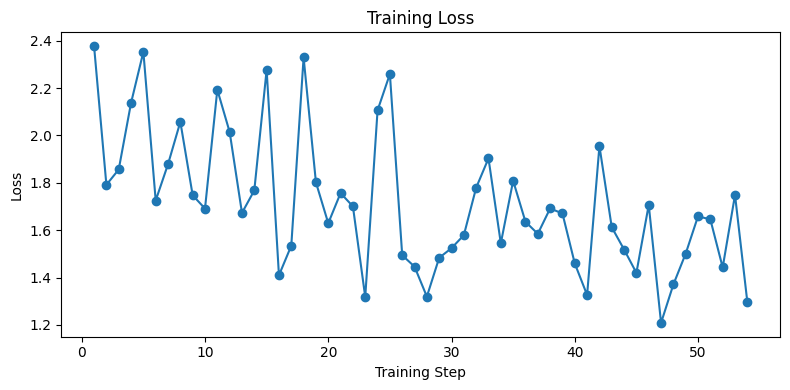

Loss log saved to: results_base_model/loss_log.txt
Loss plot saved to: results_base_model/loss_plot.png


In [15]:
#Generate and save training loss log
log_path = os.path.join(OUTPUT_DIR, "loss_log.txt")
with open(log_path, "w", encoding="utf-8") as f:
    f.write("step\ttrain_loss\n")
    for i, loss in enumerate(train_losses, start=1):
        f.write(f"{i}\t{loss:.6f}\n")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "loss_plot.png")
plt.savefig(plot_path)
plt.show()

print("Loss log saved to:", log_path)
print("Loss plot saved to:", plot_path)

# Interactive summary generation

In [16]:
@torch.no_grad()
def summarize_text(text, max_input_len=512, max_output_len=96):
    model.eval()

    # Prompt
    prompt = (
        "Summarize the following scientific text in 1–2 precise sentences. "
        "Clearly state the objective and key finding. Use specific terms and avoid vague or generic phrases.\n\n"
        f"Text:\n{text}"
    )

    enc = tokenizer(
        prompt,
        truncation=True,
        max_length=max_input_len,
        return_tensors="pt"
    ).to(device)

    # Decoding settings
    generated_ids = model.generate(
        **enc,
        max_length=96,
        min_length=25,
        num_beams=3,
        repetition_penalty=1.8,
        no_repeat_ngram_size=3,
        length_penalty=1.3,
        early_stopping=True
    )

    return tokenizer.decode(generated_ids[0], skip_special_tokens=True)

# Test generation
test_text = """
Large language models can summarize scientific papers, but they may hallucinate unsupported claims.
This project studies whether structured prompting improves faithfulness without harming summary quality.
"""

generated_summary = summarize_text(test_text)
print("Generated Summary:\n", generated_summary)

Generated Summary:
 This project studies if structured prompting improves faithfulness without harming summary quality in the context of scientific papers.


In [17]:
import shutil
from google.colab import files

shutil.make_archive(OUTPUT_DIR, 'zip', OUTPUT_DIR)
files.download(f"{OUTPUT_DIR}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Loading Base Model and Evaluate

In [18]:
BASE_MODEL_NAME = "google/flan-t5-small"
OUTPUT_DIR = "results_final"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load base model
base_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL_NAME).to(device)

# Count parameters
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    pct = 100 * trainable / total
    return total, trainable, pct

base_total, base_trainable, base_pct = count_parameters(base_model)

# Evaluate base model
base_val_loss = evaluate_loss(base_model, val_loader)
base_rouge, base_preds, base_refs = evaluate_rouge(base_model, val_loader)

print("BASE MODEL RESULTS")
print("Validation loss:", base_val_loss)
print(base_rouge)
print(f"Total params: {base_total:,}")
print(f"Trainable params: {base_trainable:,}")
print(f"Trainable %: {base_pct:.4f}%")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


BASE MODEL RESULTS
Validation loss: 1.4906741976737976
{'rouge1': np.float64(0.3879780826983235), 'rouge2': np.float64(0.23609354893450857), 'rougeL': np.float64(0.3243698706208983), 'rougeLsum': np.float64(0.32368775175276643)}
Total params: 76,961,152
Trainable params: 76,961,152
Trainable %: 100.0000%


# Adding LoRA to FLAN-T5

In [19]:
# Reload clean base model for LoRA adaptation
lora_base_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL_NAME).to(device)

# LoRA configuration
lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=16,                         # LoRA rank
    lora_alpha=32,               # scaling factor
    lora_dropout=0.05,           # regularization
    target_modules=["q", "k", "v", "o", "wi", "wo"],
    bias="none"
)

# Wrap model with LoRA
lora_model = get_peft_model(lora_base_model, lora_config)
lora_model.to(device)

# Print trainable parameters
lora_model.print_trainable_parameters()

lora_total, lora_trainable, lora_pct = count_parameters(lora_model)

print(f"LoRA total params: {lora_total:,}")
print(f"LoRA trainable params: {lora_trainable:,}")
print(f"LoRA trainable %: {lora_pct:.4f}%")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


trainable params: 1,769,472 || all params: 78,730,624 || trainable%: 2.2475
LoRA total params: 78,730,624
LoRA trainable params: 1,769,472
LoRA trainable %: 2.2475%


# Training LoRA Model

In [20]:
# LoRA training hyperparameters
LORA_LR = 3e-4
LORA_EPOCHS = 15
GRAD_ACCUM_STEPS = 2
WEIGHT_DECAY = 0.01

optimizer = torch.optim.AdamW(
    lora_model.parameters(),
    lr=LORA_LR,
    weight_decay=WEIGHT_DECAY
)

num_update_steps_per_epoch = max(1, math.ceil(len(train_loader) / GRAD_ACCUM_STEPS))
max_train_steps = LORA_EPOCHS * num_update_steps_per_epoch
warmup_steps = max(1, int(0.1 * max_train_steps))

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=max_train_steps
)

lora_train_losses = []
lora_val_losses = []
best_lora_val_loss = float("inf")
global_step = 0

for epoch in range(LORA_EPOCHS):
    lora_model.train()
    epoch_loss = 0.0
    step_count = 0

    optimizer.zero_grad()

    print(f"\n========== LoRA Epoch {epoch+1}/{LORA_EPOCHS} ==========")

    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = lora_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss / GRAD_ACCUM_STEPS

        if not torch.isfinite(loss):
            raise ValueError(f"Non-finite LoRA loss at step {global_step}: {loss.item()}")

        loss.backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

        actual_loss = loss.item() * GRAD_ACCUM_STEPS
        lora_train_losses.append(actual_loss)
        epoch_loss += actual_loss
        step_count += 1

        print(f"Epoch {epoch+1} | Batch {step+1}/{len(train_loader)} | Loss: {actual_loss:.4f}")

    avg_train_loss = epoch_loss / max(1, step_count)
    val_loss = evaluate_loss(lora_model, val_loader)
    lora_val_losses.append(val_loss)

    print(f"\nLoRA Epoch {epoch+1} Summary")
    print(f"Average train loss: {avg_train_loss:.4f}")
    print(f"Validation loss:   {val_loss:.4f}")

    if val_loss < best_lora_val_loss:
        best_lora_val_loss = val_loss
        save_dir = os.path.join(OUTPUT_DIR, "lora_adapter")
        os.makedirs(save_dir, exist_ok=True)
        lora_model.save_pretrained(save_dir)
        tokenizer.save_pretrained(save_dir)
        print("Best LoRA adapter saved to:", save_dir)


========== LoRA Epoch 1/15 ==========
Epoch 1 | Batch 1/18 | Loss: 2.0636
Epoch 1 | Batch 2/18 | Loss: 2.0113
Epoch 1 | Batch 3/18 | Loss: 1.7991
Epoch 1 | Batch 4/18 | Loss: 2.1613
Epoch 1 | Batch 5/18 | Loss: 1.9166
Epoch 1 | Batch 6/18 | Loss: 2.0460
Epoch 1 | Batch 7/18 | Loss: 1.9611
Epoch 1 | Batch 8/18 | Loss: 2.0214
Epoch 1 | Batch 9/18 | Loss: 1.9862
Epoch 1 | Batch 10/18 | Loss: 2.6523
Epoch 1 | Batch 11/18 | Loss: 2.3300
Epoch 1 | Batch 12/18 | Loss: 1.9949
Epoch 1 | Batch 13/18 | Loss: 1.9013
Epoch 1 | Batch 14/18 | Loss: 2.0083
Epoch 1 | Batch 15/18 | Loss: 1.9850
Epoch 1 | Batch 16/18 | Loss: 1.7374
Epoch 1 | Batch 17/18 | Loss: 1.7736
Epoch 1 | Batch 18/18 | Loss: 1.9030

LoRA Epoch 1 Summary
Average train loss: 2.0140
Validation loss:   1.4202
Best LoRA adapter saved to: results_final/lora_adapter

========== LoRA Epoch 2/15 ==========
Epoch 2 | Batch 1/18 | Loss: 2.1263
Epoch 2 | Batch 2/18 | Loss: 1.8228
Epoch 2 | Batch 3/18 | Loss: 2.0097
Epoch 2 | Batch 4/18 | Loss

# Evaluating LoRA Model

In [21]:
lora_val_loss = evaluate_loss(lora_model, val_loader)
lora_rouge, lora_preds, lora_refs = evaluate_rouge(lora_model, val_loader)

print("LoRA MODEL RESULTS")
print("Validation loss:", lora_val_loss)
print(lora_rouge)
print(f"Total params: {lora_total:,}")
print(f"Trainable params: {lora_trainable:,}")
print(f"Trainable %: {lora_pct:.4f}%")

LoRA MODEL RESULTS
Validation loss: 0.4016454592347145
{'rouge1': np.float64(0.7180078626984555), 'rouge2': np.float64(0.6021724943032661), 'rougeL': np.float64(0.6686828268114665), 'rougeLsum': np.float64(0.6717513336240084)}
Total params: 78,730,624
Trainable params: 1,769,472
Trainable %: 2.2475%


# Comparison Table

In [22]:
comparison = pd.DataFrame([
    {
        "System": "Base FLAN-T5-small",
        "Adaptation": "None",
        "Total Params": base_total,
        "Trainable Params": base_trainable,
        "Trainable %": round(base_pct, 4),
        "Val Loss": round(base_val_loss, 4),
        "ROUGE-1": round(base_rouge["rouge1"], 4),
        "ROUGE-2": round(base_rouge["rouge2"], 4),
        "ROUGE-L": round(base_rouge["rougeL"], 4),
    },
    {
        "System": "LoRA FLAN-T5-small",
        "Adaptation": "LoRA r=16, alpha=32, dropout=0.05",
        "Total Params": lora_total,
        "Trainable Params": lora_trainable,
        "Trainable %": round(lora_pct, 4),
        "Val Loss": round(lora_val_loss, 4),
        "ROUGE-1": round(lora_rouge["rouge1"], 4),
        "ROUGE-2": round(lora_rouge["rouge2"], 4),
        "ROUGE-L": round(lora_rouge["rougeL"], 4),
    }
])

comparison_path = os.path.join(OUTPUT_DIR, "base_vs_lora_comparison.csv")
comparison.to_csv(comparison_path, index=False)

print("Base vs LoRA Comparison Table")
display(comparison)

print("Saved comparison table to:", comparison_path)

Base vs LoRA Comparison Table


,System,Adaptation,Total Params,Trainable Params,Trainable %,Val Loss,ROUGE-1,ROUGE-2,ROUGE-L
0,Base FLAN-T5-small,None,76961152,76961152,100.0000,1.4907,0.388,0.2361,0.3244
1,LoRA FLAN-T5-small,"LoRA r=16, alpha=32, dropout=0.05",78730624,1769472,2.2475,0.4016,0.718,0.6022,0.6687


Saved comparison table to: results_final/base_vs_lora_comparison.csv


# Saving Sample Outputs

In [23]:
sample_outputs = []

for i in range(min(5, len(base_preds), len(lora_preds))):
    sample_outputs.append({
        "Example": i + 1,
        "Reference Summary": base_refs[i],
        "Base Output": base_preds[i],
        "LoRA Output": lora_preds[i]
    })

sample_df = pd.DataFrame(sample_outputs)

sample_path = os.path.join(OUTPUT_DIR, "sample_outputs_base_vs_lora.csv")
sample_df.to_csv(sample_path, index=False)

display(sample_df)

print("Saved sample outputs to:", sample_path)

,Example,Reference Summary,Base Output,LoRA Output
0,1,The paper investigates retrieval-augmented gen...,A method for retrieval-augmented generation of...,This work uses structured prompting to improve...
1,2,This work applies human-in-the-loop error anal...,Human-in-the-loop error analysis can support d...,This study investigates domain adaptation usin...
2,3,The research addresses model calibration using...,A method for encoding document encoders is use...,This study uses section-wise document encoding...
3,4,The research addresses attention-based summari...,Summarization metrics and qualitative analysis...,This study investigates structured prompting w...
4,5,This study uses attention-based sequence-to-se...,This study focuses on document-level generatio...,This study uses attention-based sequence-to-se...


Saved sample outputs to: results_final/sample_outputs_base_vs_lora.csv


# Ploting Base vs LoRA Metrics

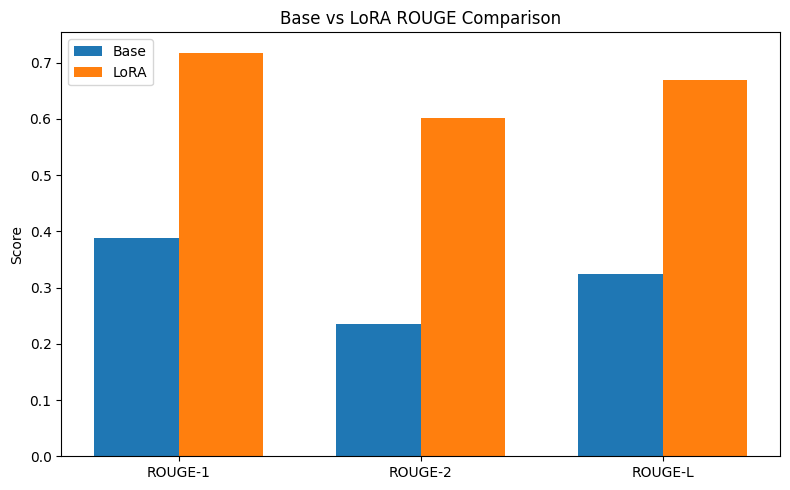

Saved plot to: results_final/base_vs_lora_rouge.png


In [24]:
metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]

base_scores = [
    base_rouge["rouge1"],
    base_rouge["rouge2"],
    base_rouge["rougeL"]
]

lora_scores = [
    lora_rouge["rouge1"],
    lora_rouge["rouge2"],
    lora_rouge["rougeL"]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, base_scores, width, label="Base")
plt.bar(x + width/2, lora_scores, width, label="LoRA")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Base vs LoRA ROUGE Comparison")
plt.legend()
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "base_vs_lora_rouge.png")
plt.savefig(plot_path)
plt.show()

print("Saved plot to:", plot_path)

# Example summary from the LoRA-adapted model

In [25]:
# Generate example outputs from LoRA-adapted model
@torch.no_grad()
def generate_lora_summary(text, max_input_len=512, max_output_len=96):
    lora_model.eval()

    prompt = (
        "Summarize the following scientific text in 1-2 precise sentences. "
        "Clearly state the objective and key finding.\n\n"
        f"Text:\n{text}"
    )

    enc = tokenizer(
        prompt,
        truncation=True,
        max_length=max_input_len,
        return_tensors="pt"
    ).to(device)

    generated_ids = lora_model.generate(
        **enc,
        max_length=max_output_len,
        min_length=25,
        num_beams=3,
        repetition_penalty=1.8,
        no_repeat_ngram_size=3,
        length_penalty=1.2,
        early_stopping=True
    )

    return tokenizer.decode(generated_ids[0], skip_special_tokens=True)


# Show examples from validation set
examples = []

for i, row in enumerate(val_data[:5]):
    input_text = row["paper_text"]
    reference = row["summary"]
    lora_output = generate_lora_summary(input_text)

    examples.append({
        "Example": i + 1,
        "Input Text": input_text,
        "Reference Summary": reference,
        "LoRA Output": lora_output
    })

example_df = pd.DataFrame(examples)
display(example_df)

# Save examples
example_df.to_csv("results_final/lora_example_outputs.csv", index=False)
print("Saved to: results_final/lora_example_outputs.csv")

,Example,Input Text,Reference Summary,LoRA Output
0,1,Large language models have shown strong perfor...,The paper investigates retrieval-augmented gen...,This work uses structured prompting to improve...
1,2,This research investigates how human-in-the-lo...,This work applies human-in-the-loop error anal...,This study investigates domain adaptation usin...
2,3,This research investigates how section-wise do...,The research addresses model calibration using...,This study uses section-wise document encoding...
3,4,This research investigates how structured prom...,The research addresses attention-based summari...,This study investigates structured prompting w...
4,5,Scientific documents are difficult to summariz...,This study uses attention-based sequence-to-se...,This study uses attention-based sequence-to-se...


Saved to: results_final/lora_example_outputs.csv


# From a single custom text

In [26]:
custom_text = """
Scientific summarization is challenging because generated summaries must preserve factual consistency
while compressing dense technical information. This study evaluates whether LoRA adaptation improves
summary quality for scientific text.
"""

print(generate_lora_summary(custom_text))

This study uses LoRA adaptation to improve summary quality for scientific text, showing that it improves summary quality with respect to generated summaries.


In [27]:
import shutil
from google.colab import files

shutil.make_archive(OUTPUT_DIR, 'zip', OUTPUT_DIR)
files.download(f"{OUTPUT_DIR}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>